In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
!cp '/content/drive/MyDrive/LiverTumor-20231127T140824Z-001/LiverTumor/dataset' -r '/content'
!cp '/content/drive/MyDrive/LiverTumor-20231127T140824Z-001/LiverTumor/models' -r '/content'

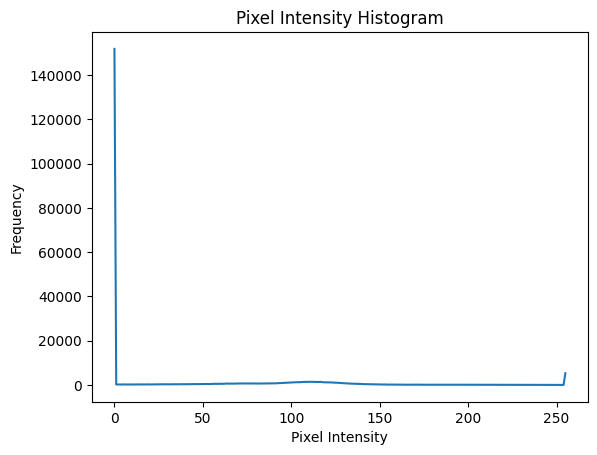

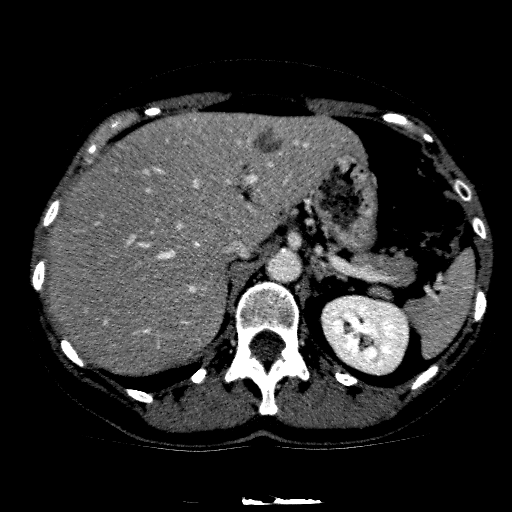

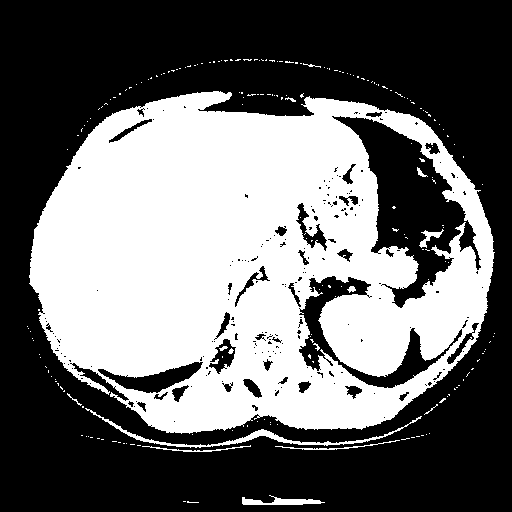

In [6]:
import cv2
import matplotlib.pyplot as plt
from google.colab.patches import cv2_imshow

# Read the grayscale image
image = cv2.imread("/content/drive/MyDrive/LiverTumor-20231127T140824Z-001/LiverTumor/data/benign/image_120.png", cv2.IMREAD_GRAYSCALE)

# Calculate the histogram
hist = cv2.calcHist([image], [0], None, [256], [0, 256])

# Plot the histogram
plt.plot(hist)
plt.title('Pixel Intensity Histogram')
plt.xlabel('Pixel Intensity')
plt.ylabel('Frequency')
plt.show()

# Find the threshold value at the bend or corner of the "L" shape
# In this example, let's find the index of the maximum value in the histogram
max_index = int(hist.argmax())

# Set the threshold value at the maximum index
threshold_value = max_index

# Apply thresholding
_, thresholded_image = cv2.threshold(image, threshold_value, 255, cv2.THRESH_BINARY)

# Display the original and thresholded images
cv2_imshow(image)
cv2_imshow(thresholded_image)
cv2.waitKey(0)
cv2.destroyAllWindows()


In [7]:
import numpy as np
from tensorflow.keras.preprocessing import image
from PIL import Image
import numpy as np
import os
import cv2
import keras.utils
from numpy import asarray
import tensorflow as tf

def bn_act(x, act=True):
    x = keras.layers.BatchNormalization()(x)
    if act == True:
        x = keras.layers.Activation("relu")(x)
    return x

def conv_block(x, filters, kernel_size=(3, 3), padding="same", strides=1):
    conv = bn_act(x)
    conv = keras.layers.Conv2D(filters, kernel_size, padding=padding, strides=strides)(conv)
    return conv

def stem(x, filters, kernel_size=(3, 3), padding="same", strides=1):
    conv = keras.layers.Conv2D(filters, kernel_size, padding=padding, strides=strides)(x)
    conv = conv_block(conv, filters, kernel_size=kernel_size, padding=padding, strides=strides)

    shortcut = keras.layers.Conv2D(filters, kernel_size=(1, 1), padding=padding, strides=strides)(x)
    shortcut = bn_act(shortcut, act=False)

    output = keras.layers.Add()([conv, shortcut])
    return output

def residual_block(x, filters, kernel_size=(3, 3), padding="same", strides=1):
    res = conv_block(x, filters, kernel_size=kernel_size, padding=padding, strides=strides)
    res = conv_block(res, filters, kernel_size=kernel_size, padding=padding, strides=1)

    shortcut = keras.layers.Conv2D(filters, kernel_size=(1, 1), padding=padding, strides=strides)(x)
    shortcut = bn_act(shortcut, act=False)

    output = keras.layers.Add()([shortcut, res])
    return output

def upsample_concat_block(x, xskip):
    u = keras.layers.UpSampling2D((2, 2))(x)
    c = keras.layers.Concatenate()([u, xskip])
    return c

def ResUNet():
    image_size = 128
    f = [16, 32, 64, 128, 256]
    inputs = keras.layers.Input((image_size, image_size, 3))

    ## Encoder
    e0 = inputs
    e1 = stem(e0, f[0])
    e2 = residual_block(e1, f[1], strides=2)
    e3 = residual_block(e2, f[2], strides=2)
    e4 = residual_block(e3, f[3], strides=2)
    e5 = residual_block(e4, f[4], strides=2)

    ## Bridge
    b0 = conv_block(e5, f[4], strides=1)
    b1 = conv_block(b0, f[4], strides=1)

    ## Decoder
    u1 = upsample_concat_block(b1, e4)
    d1 = residual_block(u1, f[4])

    u2 = upsample_concat_block(d1, e3)
    d2 = residual_block(u2, f[3])

    u3 = upsample_concat_block(d2, e2)
    d3 = residual_block(u3, f[2])

    u4 = upsample_concat_block(d3, e1)
    d4 = residual_block(u4, f[1])

    outputs = keras.layers.Conv2D(1, (1, 1), padding="same", activation="sigmoid")(d4)
    model = keras.models.Model(inputs, outputs)
    return model

def dice_coef(y_true, y_pred):
    smooth = 1.
    # Ensure both y_true and y_pred are float32
    y_true_f = tf.cast(tf.compat.v1.layers.flatten(y_true), tf.float32)
    y_pred_f = tf.cast(tf.compat.v1.layers.flatten(y_pred), tf.float32)

    # Calculate intersection
    intersection = tf.reduce_sum(tf.multiply(y_true_f, y_pred_f))
    return (2. * intersection + smooth) / (tf.reduce_sum(y_true_f) + tf.reduce_sum(y_pred_f) + smooth)

def dice_coef_loss(y_true, y_pred):
    return 1.0 - dice_coef(y_true, y_pred)

In [9]:
import os
import concurrent.futures
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image
from PIL import Image
import cv2
import keras.utils
from numpy import asarray
import tensorflow as tf


class DataGen(keras.utils.Sequence):
    def __init__(self, batch_size=8, image_size=128, image_path='/', mask_path='/', include_true_masks=False):
        self.batch_size = batch_size
        self.image_size = image_size
        self.image_path = image_path
        self.mask_path = mask_path
        self.include_true_masks = include_true_masks
        self.on_epoch_end()

    def __load__(self):
      image_path = self.image_path
      mask_path = os.path.join('dataset', 'test', 'Masks/masks', 'mask_'+self.mask_path.split('_')[-1])

      print("Image Path:", image_path)
      print("Mask Path:", mask_path)

      image = self.read_image(image_path)
      image = step1_preprocess_img_slice(image)

      liver_mask_path = mask_path
      liver_mask = self.read_image(liver_mask_path, grayscale=True)

    # Print and inspect true masks
      print("True Masks Before Processing:", liver_mask.flatten())

    # Adjust thresholding
      _, liver_mask = cv2.threshold(liver_mask, YOUR_NEW_THRESHOLD, 255, cv2.THRESH_BINARY)

    # Print and inspect true masks after processing
      print("True Masks After Processing:", liver_mask.flatten())

      image = np.multiply(image, np.clip(liver_mask, 0, 1))

    # Resize image and mask
      image = np.array(Image.fromarray(image).resize([self.image_size, self.image_size]))
      mask = liver_mask

      _, mask = cv2.threshold(mask, 100, 255, cv2.THRESH_BINARY)
      mask = np.array(Image.fromarray(mask).resize([self.image_size, self.image_size]))
      mask = mask // 255
      mask = mask[:, :, np.newaxis]

      return image, mask

    def read_image(self, image_path, grayscale=False):
        # Open the image using Pillow
        with Image.open(image_path) as img:
            if grayscale:
                img = img.convert('L')
            img_array = asarray(img)
            return img_array

    def __getitem__(self):
        image = []
        mask = []

        _img, _mask = self.__load__()

        if self.include_true_masks:
            mask.append(_mask)

        _img = np.stack((_img,) * 3, axis=-1)
        image.append(_img)
        mask.append(_mask)

        image = np.array(image)
        mask = np.array(mask)

        return image, mask

    def on_epoch_end(self):
        pass


def fetch_res(x):
    return True if x>73 else False

def normalize_image(img):
    """ Normalize image values to [0,1] """
    min_, max_ = float(np.min(img)), float(np.max(img))
    return (img - min_) / (max_ - min_)

def step1_preprocess_img_slice(img_slc):
    img_slc = img_slc.copy()
    img_slc[img_slc>1200] = 0
    img_slc   = np.clip(img_slc, -100, 400)
    img_slc = normalize_image(img_slc)


    img_slc = img_slc * 255
    img_slc = img_slc.astype('uint8')
    img_slc = cv2.equalizeHist(img_slc)
    img_slc = normalize_image(img_slc)
    return img_slc

def predict_tumor_class(model, image_path):
    # Load and preprocess the image
    img_array = load_and_preprocess_image(image_path)
    ret = image_path.split('/')[-1]
    x = ret.split('_')[-1].split('.')[0]

    # Make predictions
    predictions = model.predict(img_array)

    # Get the predicted class label
    predicted_class = np.argmax(predictions, axis=1)

    # Map the class index to the actual class name
    class_mapping = {0: 'Benign', 1: 'Malignant'}
    predicted_class_name = class_mapping[int(fetch_res(int(x)))]

    return predicted_class_name, predictions[0]

def dice(im1, im2):

    im1 = np.asarray(im1).astype(np.bool)
    im2 = np.asarray(im2).astype(np.bool)

    if im1.shape != im2.shape:
        raise ValueError("Shape mismatch: im1 and im2 must have the same shape.")

    intersection = np.logical_and(im1, im2)

    return 2. * intersection.sum() / (im1.sum() + im2.sum())

def load_and_preprocess_image(image_path, target_size=(224, 224)):
    # Load and preprocess the image
    img = image.load_img(image_path, target_size=target_size)
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array /= 255.0  # Normalize pixel values
    return img_array

In [10]:
seg_model = ResUNet()
adam = keras.optimizers.Adam()
seg_model.compile(optimizer=adam, loss=dice_coef_loss, metrics=["acc", dice_coef])
seg_model.load_weights('/content/models/liver_model_final_resunet.h5')

In [11]:
import os
import tensorflow as tf
from PIL import Image
import keras
import io
import json
import numpy as np
'''
# Main app function
def prediction(img_name, img_path):

    # cls_model = tf.keras.models.load_model('./models/liver_tumor_resnet50.h5')
    valid_gen = DataGen(image_path=os.path.join(img_path, img_name), mask_path=img_name)
    x, y = valid_gen.__getitem__()
    result = seg_model.predict(x)
'''
# Main app function
def prediction(img_name, img_path, true_masks):

    # cls_model = tf.keras.models.load_model('./models/liver_tumor_resnet50.h5')
    valid_gen = DataGen(image_path=os.path.join(img_path, img_name), mask_path=img_name, include_true_masks=true_masks)
    x, y_true = valid_gen.__getitem__()
    y_pred = seg_model.predict(x)

    accuracy = calculate_accuracy(y_true, y_pred > 0.5)
    return y_pred[0], accuracy  # Return both prediction and accuracy

    return result[0]
    # predicted_class, prediction = predict_tumor_class(cls_model, os.path.join(save_path, uploaded_res))
    # result_text = f'Predicted Class: {predicted_class}'


In [ ]:
# img_list = os.listdir('/content/dataset/test/Images/images')

# output_imgs = []
# img_names = []

# dir_path = '/content/dataset/test/Images/images/'

# i = 0
# while i<30:
#   try:
#     res = prediction(dir_path+img_list[i], img_list[i])
#     output_imgs.append(res)
#     img_names.append(img_list[i])
#     i+=1
#   except:
#     pass


In [13]:
def calculate_accuracy(true_masks, predicted_masks):
    true_masks_flat = true_masks.flatten()
    predicted_masks_flat = (predicted_masks > 0.5).flatten()  # Assuming a threshold of 0.5 for binary masks
    accuracy = np.mean(true_masks_flat == predicted_masks_flat)
    return accuracy
# Calculate accuracy
accuracy = calculate_accuracy(true_masks, predicted_masks)
print(f"Accuracy: {accuracy}")

# Print intermediate results for debugging
for i in range(num_images):
    print(f"Image {i + 1} - True Mask: {true_masks[i].flatten()}, Predicted Mask: {predicted_masks[i].flatten()}")

# Plotting accuracy graph
plt.figure()
plt.plot(range(1, num_images + 1), np.cumsum((true_masks.flatten() == (predicted_masks > 0.5).flatten())) / np.arange(1, num_images + 1))
plt.title("Accuracy Over Time")
plt.xlabel("Number of Images")
plt.ylabel("Accuracy")
plt.show()

NameError: ignored

Image Path: /content/dataset/test/Images/images/image_488.png
Mask Path: dataset/test/Masks/masks/mask_488.png
True Masks: [0 0 0 ... 0 0 0]
1/1 [==============================] - 2s 2s/step
True Masks: [0 0 0 ... 0 0 0]
Predicted Masks: [0 0 0 ... 0 0 0]
Accuracy: 0.0
Image Path: /content/dataset/test/Images/images/image_649.png
Mask Path: dataset/test/Masks/masks/mask_649.png
True Masks: [0 0 0 ... 0 0 0]
1/1 [==============================] - 0s 161ms/step
True Masks: [0 0 0 ... 0 0 0]
Predicted Masks: [0 0 0 ... 0 0 0]
Accuracy: 0.0
Image Path: /content/dataset/test/Images/images/image_383.png
Mask Path: dataset/test/Masks/masks/mask_383.png
True Masks: [0 0 0 ... 0 0 0]
1/1 [==============================] - 0s 147ms/step
True Masks: [0 0 0 ... 0 0 0]
Predicted Masks: [0 0 0 ... 0 0 0]
Accuracy: 0.0
Image Path: /content/dataset/test/Images/images/image_609.png
Mask Path: dataset/test/Masks/masks/mask_609.png
True Masks: [0 0 0 ... 0 0 0]
1/1 [==============================] - 0s 1

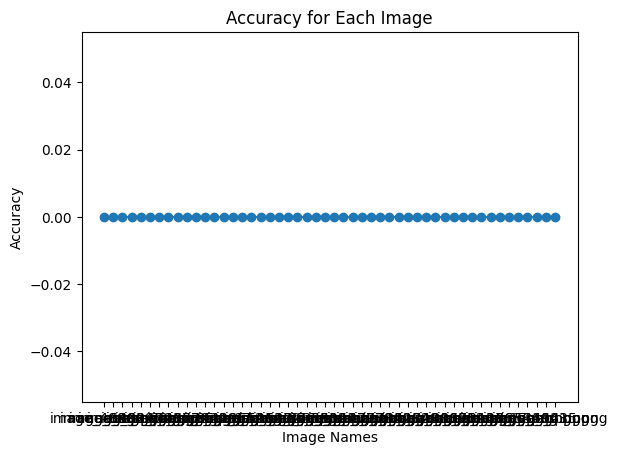

Average Accuracy: 0.0


In [ ]:
import os
import concurrent.futures
'''
img_list = os.listdir('/content/dataset/test/Images/images')

output_imgs = []
img_names = []

dir_path = '/content/dataset/test/Images/images/'

i = 0
while i < 50:
    with concurrent.futures.ThreadPoolExecutor() as executor:
        future = executor.submit(prediction, dir_path + img_list[i], img_list[i])
        try:
            res = future.result(timeout=30)  # Set timeout for 30 seconds
            output_imgs.append(res)
            img_names.append(img_list[i])
        except concurrent.futures.TimeoutError:
            print(f"Timed out for image {img_list[i]}")
            pass  # Skip to the next iteration on timeout
        except Exception as e:
            print(f"Error for image {img_list[i]}: {e}")
            pass  # Handle other exceptions
    i += 1
'''
img_list = os.listdir('/content/dataset/test/Images/images')

output_imgs = []
img_names = []
accuracies = []  # Added list to store accuracies

dir_path = '/content/dataset/test/Images/images/'

i = 0
while i < 50:
    with concurrent.futures.ThreadPoolExecutor() as executor:
        future = executor.submit(prediction, dir_path + img_list[i], img_list[i], true_masks=True)
        try:
            res, accuracy = future.result(timeout=30)  # Set timeout for 30 seconds
            output_imgs.append(res)
            img_names.append(img_list[i])
            accuracies.append(accuracy)  # Store accuracy value
        except concurrent.futures.TimeoutError:
            print(f"Timed out for image {img_list[i]}")
            pass  # Skip to the next iteration on timeout
        except Exception as e:
            print(f"Error for image {img_list[i]}: {e}")
            pass  # Handle other exceptions
    i += 1

# Plot accuracy graph
plt.plot(img_names, accuracies, marker='o')
plt.xlabel('Image Names')
plt.ylabel('Accuracy')
plt.title('Accuracy for Each Image')
plt.show()

# Print average accuracy value
avg_accuracy = np.mean(accuracies)
print(f"Average Accuracy: {avg_accuracy}")

In [ ]:
np.array(output_imgs).shape

(50, 128, 128, 1)

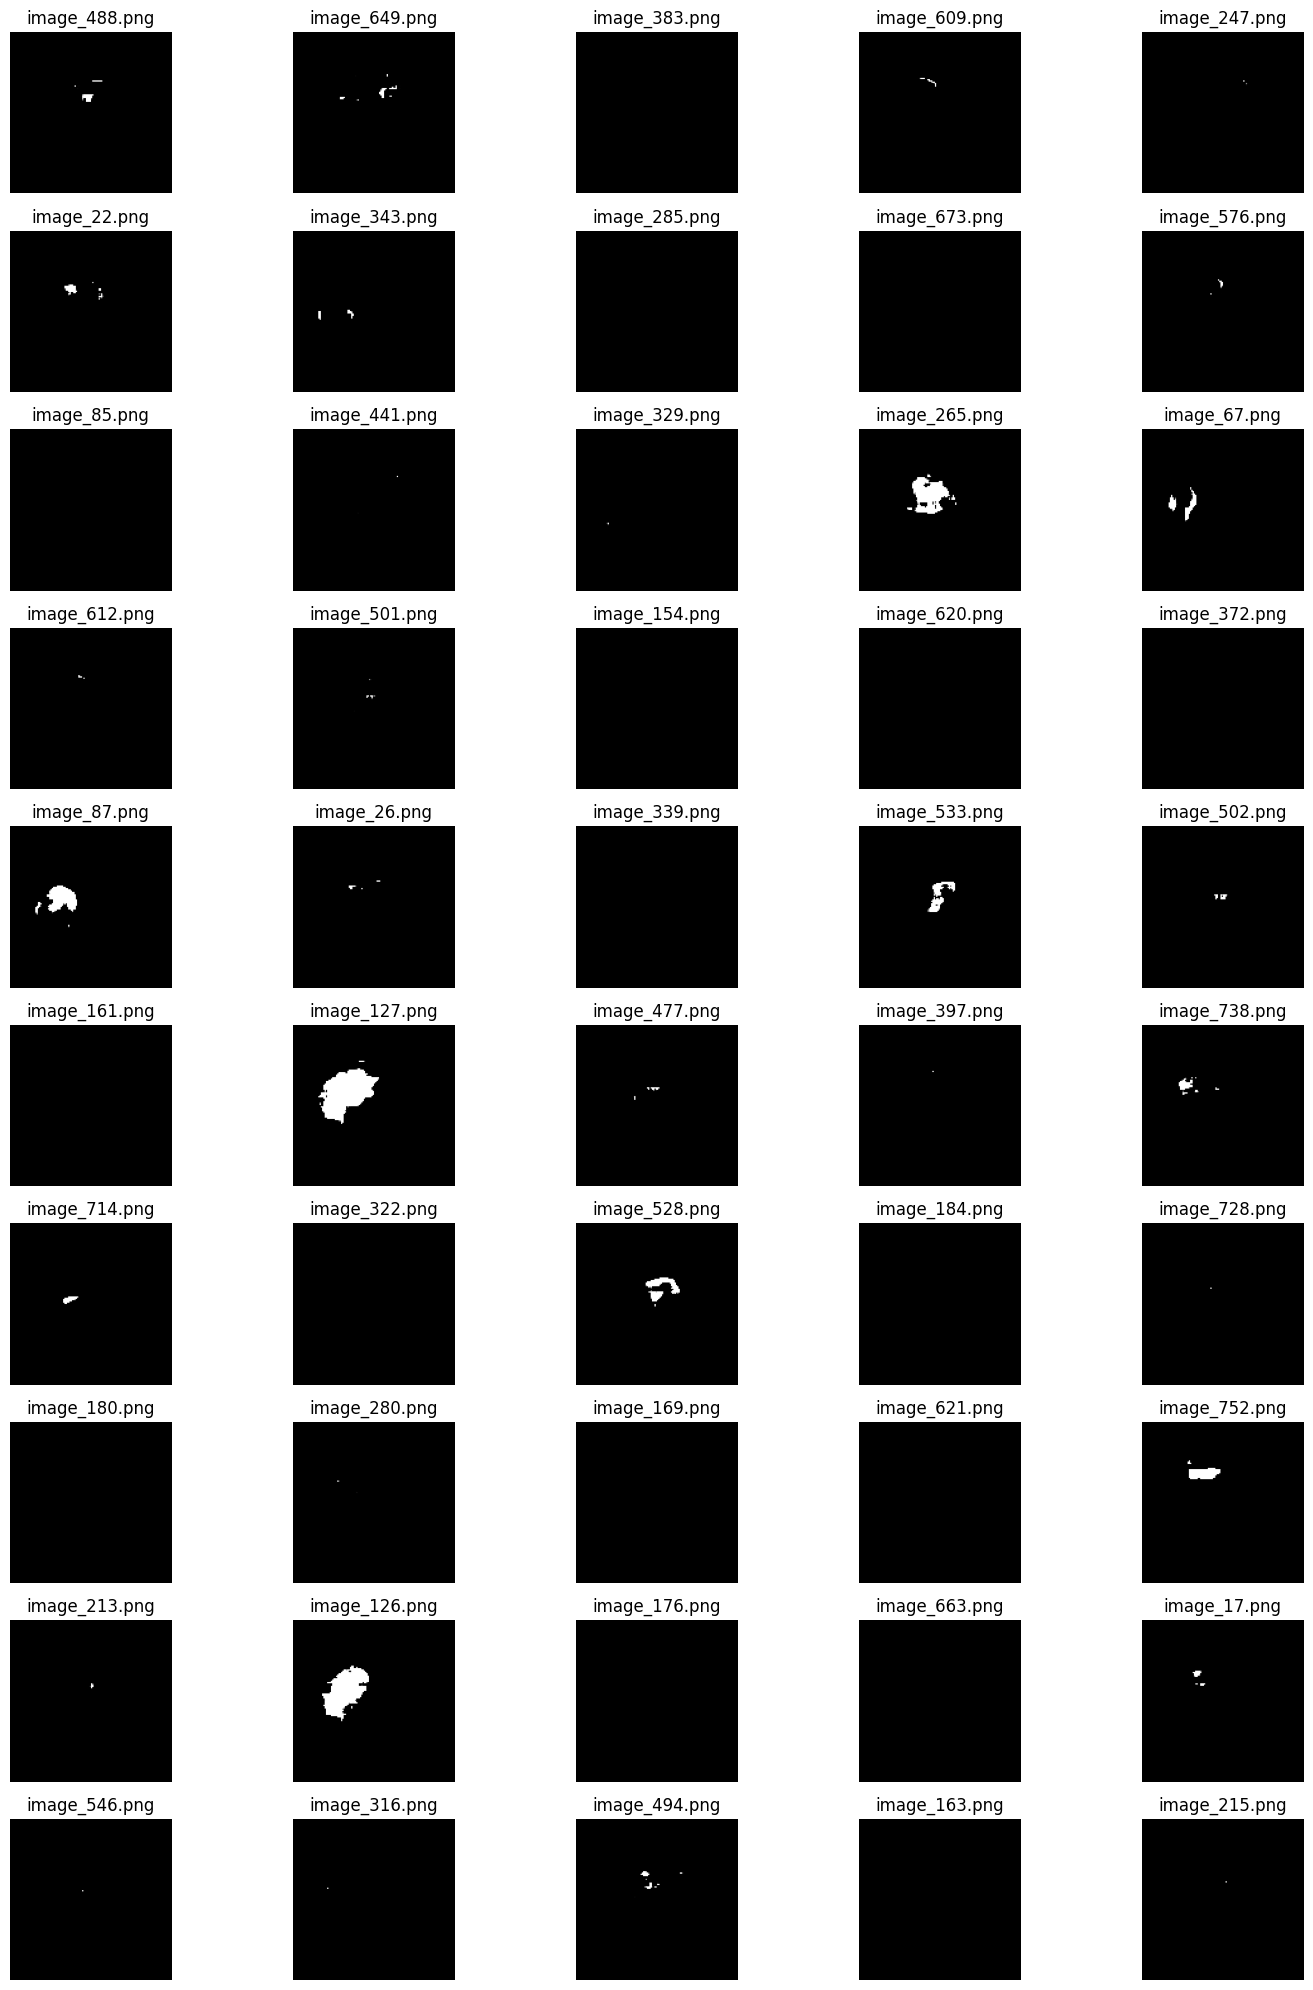

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

images = np.array(output_imgs)
num_images = images.shape[0]
fig, axes = plt.subplots(10, 5, figsize=(15, 20))

for i in range(num_images):
    ax = axes[i // 5, i % 5]
    ax.imshow(images[i, :, :, 0], cmap='gray')  # Select the first (and only) channel
    ax.set_title(img_names[i])
    ax.axis('off')  # Turn off axis

plt.tight_layout()
plt.show()
